In [ ]:
import pyart
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import cartopy.crs as ccrs
from pyproj import Proj, CRS, Transformer
import glob
import xarray as xr
from datetime import datetime, timedelta
import pandas as pd
from scipy.interpolate import griddata
from collections import defaultdict
from scipy.spatial import KDTree
import os
from sklearn.neighbors import KNeighborsRegressor
from matplotlib import colors


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# Program Inputs for which day in question
year = '2025'
month = '03'
day = '13'

# Important parameters
a = 18 
aHigh = 43
aLow = 11
b = 1.1

theta = 18
 



In [7]:
#0313

# Access directories
year = '2025'
month = '03'
day = '13'

scanningDir = '/gws/nopw/j04/tone_ico_gws/data/tone-ico_doppler_scanning_cloud_radar/L0/Y'+year+'/M'+month+'/D'+day+'/*el_18*PPI.LV1.NC'
scanningFiles = sorted(glob.glob(scanningDir))  

vertDir = '/gws/nopw/j04/tone_ico_gws/cloudnet/troll/radar/'
vertFiles = sorted(glob.glob('/gws/nopw/j04/tone_ico_gws/cloudnet/troll/radar/2025*.nc')) 

# Data processing for the 2D scanning radar
latGrid = np.empty((106, 250, 24))
lonGrid = np.empty((106, 250, 24))
rangeGrid = np.empty((106, 250, 24))
azGrid = np.empty((106, 250, 24))
dbzGrid = np.empty((106, 250, 24))
dbzCorr = np.empty((106, 250, 24))
dbzCorr_alt = np.empty((106, 250, 24))
elvGrid = np.empty((106, 250, 24))
snowGridMid = np.empty((106, 250, 24))
snowGridHigh = np.empty((106, 250, 24))
snowGridLow = np.empty((106, 250, 24))




# First extract the vertical profile data for date in question
date_prefix = f"{year}{month}{day}"
matching_files = [f for f in vertFiles if f.startswith(vertDir + date_prefix)]
vertDay = matching_files[0]
vertDs = nc.Dataset(vertDay)

dbzVert_base = np.array(vertDs.variables['Zh'])
timeVert = np.array(vertDs.variables['time'])
vertProfile = np.array(vertDs.variables['range'])
dbzVert_base[dbzVert_base > 1000] = np.nan

hour_bins = np.floor(timeVert).astype(int)

# Temporal averaging for each hour, for the vertical profile
nspace = dbzVert_base.shape[1]
dbzVert = np.full((24, nspace), np.nan)  # use NaNs in case some hours are missing

for hour in range(24):
    idx = hour_bins == hour
    if np.any(idx):
        dbzVert[hour] = np.nanmean(dbzVert_base[idx], axis=0)

# Create a vertical profile correction based on the bottom 5 elevations
baseDbz = np.mean(dbzVert[:, 0:5], axis=1) 
bigDbz = np.tile(baseDbz[:, np.newaxis], (1, 710))
vertCorrection = bigDbz - dbzVert
vertCorrect_fill = np.zeros_like(vertCorrection)

# Creating a vertical profile that will give you the elevation correction for a given elevation
for i in range(24):
    mask = ~np.isnan(vertCorrection[i])
    vertHour = vertCorrection[i]
    known = vertHour[mask]

    # Create vertical profile using nearest neighbors regression
    knr = KNeighborsRegressor(n_neighbors=5)
    knr.fit(vertProfile[mask].reshape(-1, 1), known)
    vertCorr_pred = knr.predict(vertProfile[np.isnan(vertHour)].reshape(-1, 1))

    vertTemp = vertHour.copy()
    vertTemp[np.isnan(vertHour)] = vertCorr_pred
    vertCorrect_fill[i] = vertTemp



# iterating over all the hourly radar scans during the given day, and storing in a common data structure on a common grid
k = 0
for file in scanningFiles[:2]:
    ds = xr.open_dataset(file)

    # Stack all CZE variables along the range dimension
    cze_vars = ['C1ZE45', 'C2ZE45', 'C3ZE45', 'C4ZE45']
    data_list = [ds[var].values for var in cze_vars]
    range_list = [ds[var.replace('ZE45', 'Range')].values for var in cze_vars]  

    trollLat = ds['GPSLat'].values
    trollLon = ds['GPSLon'].values

    # Concatenate data and ranges
    data_stacked = np.concatenate(data_list, axis=1)  # shape: (n_az, total_range)
    ranges_stacked = np.concatenate(range_list)       # shape: (total_range,)

    # Set all values below -30 to NaN
    data_stacked[data_stacked < -30] = np.nan

    # Generate synthetic azimuths (assuming evenly spaced)
    n_az = ds['Time'].size
    azimuths = np.linspace(0, 2 * np.pi, n_az, endpoint=False)

    # Create 2D grids for polar plot
    azimuths_2d, ranges_2d = np.meshgrid(azimuths, ranges_stacked, indexing='ij')

    # Elevation extraction
    el_deg = np.array(ds.variables['Elv'])
    elvs = np.sin(np.deg2rad(theta)) * ranges_2d

    # Projection to lat/lon
    
    X = ranges_2d * np.cos(azimuths_2d)   # Cartesian x
    Y = ranges_2d * np.sin(azimuths_2d)   # Cartesian y

    crs_centered = CRS.from_proj4(f"+proj=aeqd +lat_0={trollLat} +lon_0={trollLon} +datum=WGS84 +units=m +no_defs")
    crs_geo = CRS.from_epsg(4326)  # WGS84 lat/lon

    transformer = Transformer.from_crs(crs_centered, crs_geo, always_xy=True)

    lon, lat = transformer.transform(X, Y)

    # Initial assignment
    latGrid[:, :, k] = lat[:106, :250]  
    lonGrid[:, :, k] = lon[:106, :250]
    dbzGrid[:, :, k] = data_stacked[:106, :250]
    rangeGrid[:, :, k] = ranges_2d[:106, :250]  
    azGrid[:, :, k] = azimuths_2d[:106, :250]  
    elvGrid[:, :, k] = elvs[:106, :250]


    # Elevation correction #1: independent vertical scan

    # First find index of closest vertical profile elevation for each interpolated elevation
    elv_flat = elvGrid[:, :, k].ravel()
    flatClosest = np.full(elv_flat.shape, fill_value=-1, dtype=int)
    valid_mask = ~np.isnan(elv_flat)
    valid_values = elv_flat[valid_mask]

    idxs = np.searchsorted(vertProfile, valid_values)
    idxs_left = np.clip(idxs - 1, 0, len(vertProfile) - 1)
    idxs_right = np.clip(idxs, 0, len(vertProfile) - 1)
    dist_left = np.abs(valid_values - vertProfile[idxs_left])
    dist_right = np.abs(valid_values - vertProfile[idxs_right])
    closest_flat = np.where(dist_left <= dist_right, idxs_left, idxs_right)
    flatClosest[valid_mask] = closest_flat
    closestIndices = flatClosest.reshape(elvGrid[:, :, k].shape)

    # Apply the correction
    correctionGrid = np.zeros([106, 250])
    correctionGrid[:] = np.nan
    meanCorrect = np.mean(vertCorrect_fill, axis=0)

    for i in range(106):
        for j in range(250):
            if not np.isnan(elvGrid[i, j, k]):
                correctionGrid[i, j] = meanCorrect[closestIndices[i, j]]

    dbzCorr[:, :, k] = dbzGrid[:, :, k] + correctionGrid



In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent(2, 3, -72.15, -71.85], crs=ccrs.PlateCarree())
ax.coastlines()

cf = ax.pcolormesh(lonGrid[:, :, 18], latGrid[:, :, 18], dbzGrid[:, :, 18], transform=ccrs.PlateCarree(), cmap='viridis')
plt.colorbar(cf, label='Reflectivity (dBZ)')
plt.title("Reflectivity - no altitude correction")

plt.show()

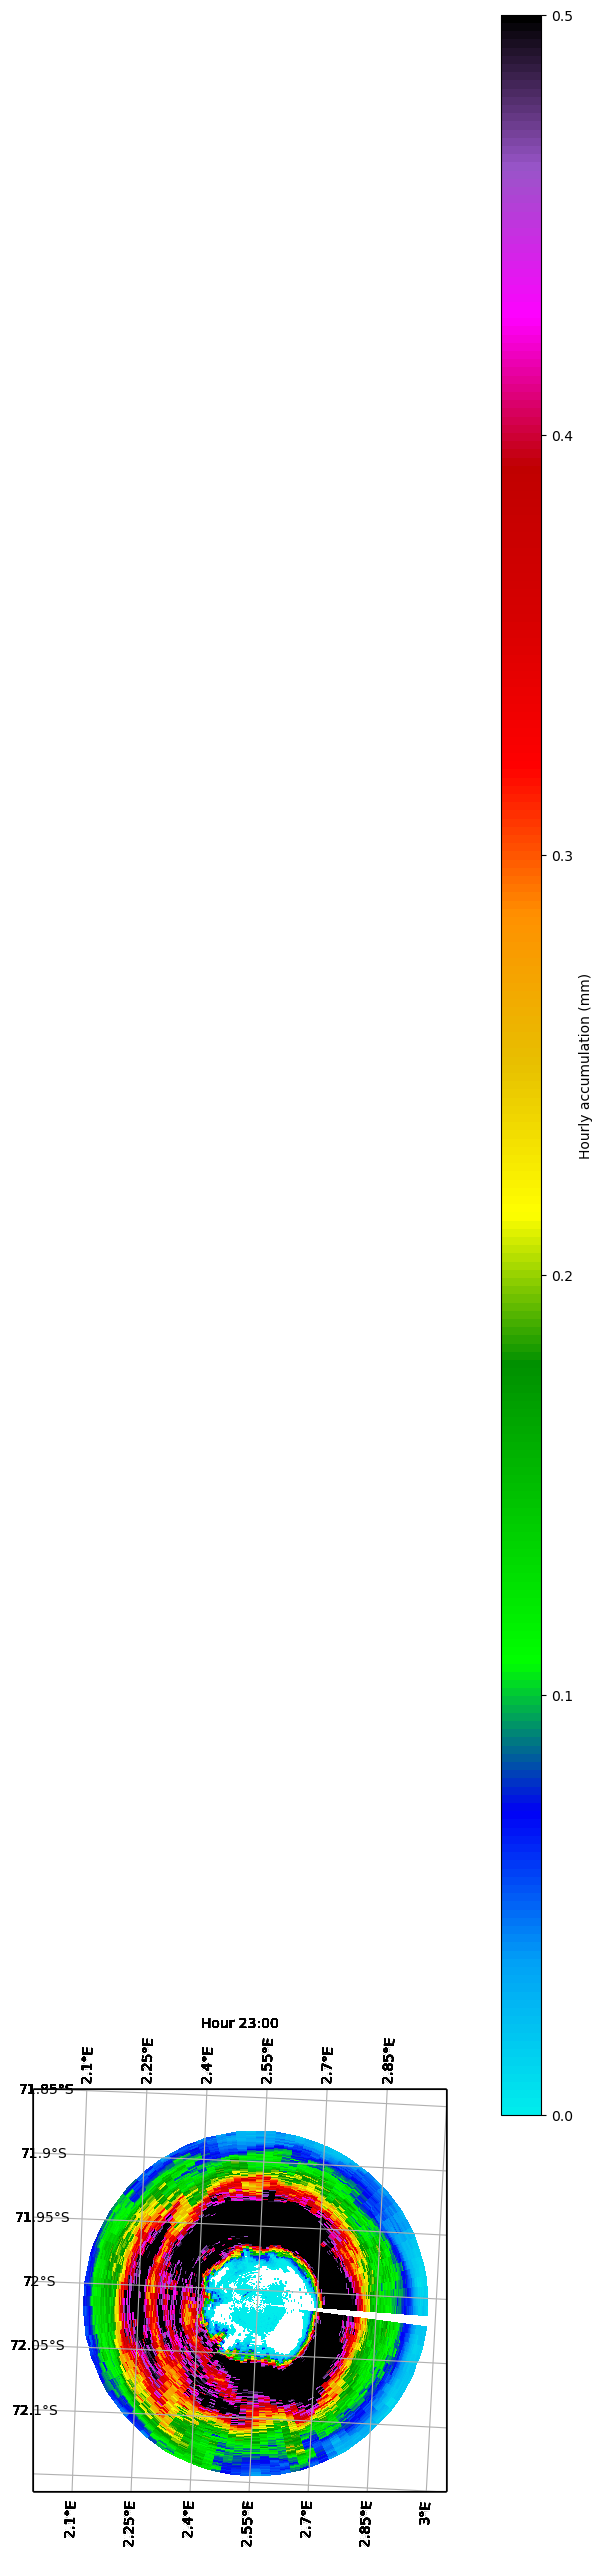

In [ ]:
# Grid layout for 24 subplots, e.g. 6 rows x 4 cols
n_rows, n_cols = 6, 4

fig = plt.figure(figsize=(20, 30))

vmin, vmax = -30, 10  # consistent color scale

for i in range(24):
    ax = fig.add_subplot(n_rows, n_cols, hour+1, projection=ccrs.SouthPolarStereo())
    
    # Set gridlines and extent
    ax.gridlines(draw_labels=True)
    ax.set_extent([2, 3, -72.15, -71.85], crs=ccrs.PlateCarree())
    ax.coastlines()
    
    # Plot data for the hour; assuming dbzCorrected_0313 is 3D: (lat, lon, time)
    pcm = ax.pcolormesh(
        lonGrid[:, :, k], latGrid[:, :, k], dbzGrid[:, :, k], 
        vmin=vmin, vmax=vmax, 
        cmap='NWSRef', 
        transform=ccrs.PlateCarree()
    )
    
    ax.set_title(f'Hour {hour:02d}:00', fontsize=10)

# Add one big colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(pcm, cax=cbar_ax, label='Hourly accumulation (mm)')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar